# Notebook 08 — Prophet Baseline: Hirsch Station
**Facebook Prophet vs SARIMAX benchmark**

Notebooks 04–07 established SARIMAX + Fourier K=4 + weather as the optimal statistical model. This notebook applies **Prophet** to Hirsch (the cleanest station, commuter-heavy) as an alternative approach with automatic seasonality detection and built-in changepoint handling.

| Part | Content |
|------|---------|
| 1 | Data loading and Prophet format preparation |
| 2 | Seasonality mode comparison (additive vs multiplicative) |
| 3 | Baseline Prophet (no weather) |
| 4 | Prophet + weather regressors |
| 5 | Performance comparison vs SARIMAX |
| 6 | Forecast visualisation |
| 7 | Artefact export and summary |

**Benchmark targets:** SARIMAX Fourier-only test RMSE = 498, SARIMAX Fourier+weather test RMSE = 471.

In [1]:
import sys, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
from prophet import Prophet

# Suppress Prophet / Stan verbosity
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})
sns.set_theme(style='whitegrid')

FIGURES = Path('../results/figures')
TABLES  = Path('../results/tables')
for p in [FIGURES, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

WEATHER_COLS = ['max_temp', 'sunshine_hours', 'precipitation']

TRAIN_START = '2013-01-01'
TRAIN_END   = '2022-12-31'
VAL_START   = '2023-01-01'
VAL_END     = '2023-12-31'
TEST_START  = '2024-01-01'
TEST_END    = '2026-04-30'

# ── Load SARIMAX benchmarks from upstream CSVs (no hardcoding) ───────────
_cross_ref  = pd.read_csv(TABLES / 'hirsch_olympia_comparison.csv')
_hirsch_row = _cross_ref[_cross_ref['Station'] == 'Hirsch'].iloc[0]
_fourier_k4 = pd.read_csv(TABLES / 'fourier_comparison.csv')
_k4_row     = _fourier_k4[_fourier_k4['K'] == 4].iloc[0]

SARIMAX_FOURIER_RMSE = float(_hirsch_row['Fourier-only RMSE'])
SARIMAX_FULL_RMSE    = float(_hirsch_row['Full model RMSE'])
SARIMAX_FOURIER_MAE  = float(_k4_row['test_7d_MAE'])
SARIMAX_FULL_MAE     = float(_hirsch_row['Full model MAE'])

# ── notebook prefix: all figures saved as nb08_<name>.png ────────────────

# Bavaria public holidays for Prophet (2013-2026)
_by_hols = holidays.Germany(state='BY', years=range(2013, 2027))
holiday_df = pd.DataFrame([
    {'ds': pd.Timestamp(d), 'holiday': name, 'lower_window': 0, 'upper_window': 0}
    for d, name in _by_hols.items()
])
NB = 'nb08'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

print(f'Setup complete.')
print(f'SARIMAX benchmarks loaded: Fourier RMSE={SARIMAX_FOURIER_RMSE}, Full RMSE={SARIMAX_FULL_RMSE}')

/Users/sousadaniela/time-series-rad/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Setup complete.
SARIMAX benchmarks loaded: Fourier RMSE=497.8, Full RMSE=471.0


## Part 1 — Data Loading and Prophet Format

Prophet expects a DataFrame with columns `ds` (datetime) and `y` (target). Weather regressors are added as additional columns.

In [2]:
df_raw = pd.read_csv('../data/processed/master_bike_data.csv', parse_dates=['date'])

# Hirsch only; fill small gaps with time interpolation
hirsch = (
    df_raw[df_raw['station'] == 'Hirsch']
    .set_index('date')
    .sort_index()[['total'] + WEATHER_COLS]
    .interpolate(method='time', limit=7)
    .dropna()
)

# Convert to Prophet format
df_prophet = hirsch.reset_index().rename(columns={'date': 'ds', 'total': 'y'})
# log1p-transform precipitation (right-skewed, matches SARIMAX pre-processing)
df_prophet['precipitation'] = np.log1p(df_prophet['precipitation'])

train_df = df_prophet[(df_prophet['ds'] >= TRAIN_START) & (df_prophet['ds'] <= TRAIN_END)].copy()
val_df   = df_prophet[(df_prophet['ds'] >= VAL_START) & (df_prophet['ds'] <= VAL_END)].copy()
test_df  = df_prophet[(df_prophet['ds'] >= TEST_START) & (df_prophet['ds'] <= TEST_END)].copy()

print(f'Train: {len(train_df):,} days  ({train_df.ds.min().date()} – {train_df.ds.max().date()})')
print(f'Val:   {len(val_df):,} days  ({val_df.ds.min().date()} – {val_df.ds.max().date()})')
print(f'Test:  {len(test_df):,} days  ({test_df.ds.min().date()} – {test_df.ds.max().date()})')
print(f'\nTarget range: {hirsch["total"].min():.0f} – {hirsch["total"].max():.0f} cyclists/day')

Train: 3,652 days  (2013-01-01 – 2022-12-31)
Val:   365 days  (2023-01-01 – 2023-12-31)
Test:  851 days  (2024-01-01 – 2026-04-30)

Target range: 0 – 3745 cyclists/day


## Part 2 — Seasonality Mode: Additive vs Multiplicative

SARIMAX analysis showed multiplicative seasonality is appropriate (weekend dip proportionally larger in summer). Testing both modes here to confirm Prophet agrees. We use val RMSE as the selection criterion.

In [3]:
def rolling_rmse_mae(y_true, y_pred, horizon=7):
    """Non-overlapping rolling window evaluation — matches SARIMAX notebooks."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    rmses, maes = [], []
    for start in range(0, n - horizon + 1, horizon):
        sl = slice(start, start + horizon)
        err = y_true[sl] - y_pred[sl]
        rmses.append(np.sqrt(np.mean(err**2)))
        maes.append(np.mean(np.abs(err)))
    return float(np.mean(rmses)), float(np.mean(maes))


def fit_prophet(train, future_df, mode='multiplicative', use_weather=False,
                changepoint_prior_scale=0.05):
    """Fit Prophet and return predictions aligned to future_df index."""
    m = Prophet(
        seasonality_mode=mode,
        holidays=holiday_df,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=changepoint_prior_scale,
    )
    if use_weather:
        for col in WEATHER_COLS:
            m.add_regressor(col)
    m.fit(train)
    forecast = m.predict(future_df)
    return forecast['yhat'].values


# Build future DataFrames (Prophet needs ds column; weather cols must be present)
val_future  = val_df[['ds'] + WEATHER_COLS].copy()
test_future = test_df[['ds'] + WEATHER_COLS].copy()

# Train on train only for mode selection
print('Testing seasonality modes on validation set...')
mode_results = {}
for mode in ['additive', 'multiplicative']:
    preds = fit_prophet(train_df, val_future[['ds']], mode=mode, use_weather=False)
    rmse, mae = rolling_rmse_mae(val_df['y'].values, preds)
    mode_results[mode] = {'Val 7d RMSE': round(rmse, 1), 'Val 7d MAE': round(mae, 1)}
    print(f'  {mode:>15s}: Val RMSE={rmse:.1f}, MAE={mae:.1f}')

best_mode = min(mode_results, key=lambda m: mode_results[m]['Val 7d RMSE'])
print(f'\nSelected seasonality mode: {best_mode}')

Testing seasonality modes on validation set...


16:16:03 - cmdstanpy - INFO - Chain [1] start processing


16:16:04 - cmdstanpy - INFO - Chain [1] done processing


         additive: Val RMSE=501.3, MAE=434.9


16:16:04 - cmdstanpy - INFO - Chain [1] start processing


16:16:04 - cmdstanpy - INFO - Chain [1] done processing


   multiplicative: Val RMSE=465.8, MAE=394.9

Selected seasonality mode: multiplicative


## Part 3 — Baseline Prophet (No Weather)

Fit Prophet with the selected seasonality mode on train data only, then evaluate on both validation and test periods.

In [4]:
print(f'Fitting baseline Prophet ({best_mode}) on train → val and test...')

# Val evaluation (train only)
base_val_preds = fit_prophet(train_df, val_future[['ds']], mode=best_mode, use_weather=False)
base_val_rmse, base_val_mae = rolling_rmse_mae(val_df['y'].values, base_val_preds)

# Test evaluation (refit on train+val for fair comparison with SARIMAX)
trainval_df = pd.concat([train_df, val_df], ignore_index=True)
base_test_preds = fit_prophet(trainval_df, test_future[['ds']], mode=best_mode, use_weather=False)
base_test_rmse, base_test_mae = rolling_rmse_mae(test_df['y'].values, base_test_preds)

print(f'Baseline Prophet ({best_mode})')
print(f'  Val  7d RMSE: {base_val_rmse:.1f}  MAE: {base_val_mae:.1f}')
print(f'  Test 7d RMSE: {base_test_rmse:.1f}  MAE: {base_test_mae:.1f}')
print(f'\n  vs SARIMAX Fourier-only: RMSE {SARIMAX_FOURIER_RMSE}, MAE {SARIMAX_FOURIER_MAE}')

Fitting baseline Prophet (multiplicative) on train → val and test...


16:16:05 - cmdstanpy - INFO - Chain [1] start processing


16:16:05 - cmdstanpy - INFO - Chain [1] done processing


16:16:05 - cmdstanpy - INFO - Chain [1] start processing


16:16:06 - cmdstanpy - INFO - Chain [1] done processing


Baseline Prophet (multiplicative)
  Val  7d RMSE: 465.8  MAE: 394.9
  Test 7d RMSE: 472.8  MAE: 400.7

  vs SARIMAX Fourier-only: RMSE 497.8, MAE 420.8


## Part 4 — Prophet + Weather Regressors

Add `max_temp`, `sunshine_hours`, and `precipitation` (log1p) as additional regressors. Prophet treats these as linear covariates, so the interpretation is similar to SARIMAX weather coefficients.

> **Note:** Prophet requires future regressor values to make predictions — we supply the actual observed weather (same as SARIMAX), so this is an in-sample regressor evaluation, not a true out-of-sample weather forecast.

In [5]:
print(f'Fitting Prophet + weather ({best_mode})...')

# Val (train only)
wx_val_preds = fit_prophet(train_df, val_future, mode=best_mode, use_weather=True)
wx_val_rmse, wx_val_mae = rolling_rmse_mae(val_df['y'].values, wx_val_preds)

# Test (train+val)
wx_test_preds = fit_prophet(trainval_df, test_future, mode=best_mode, use_weather=True)
wx_test_rmse, wx_test_mae = rolling_rmse_mae(test_df['y'].values, wx_test_preds)

print(f'Prophet + weather ({best_mode})')
print(f'  Val  7d RMSE: {wx_val_rmse:.1f}  MAE: {wx_val_mae:.1f}')
print(f'  Test 7d RMSE: {wx_test_rmse:.1f}  MAE: {wx_test_mae:.1f}')
print(f'\n  vs SARIMAX Full model: RMSE {SARIMAX_FULL_RMSE}, MAE {SARIMAX_FULL_MAE}')

weather_gain_pct = round((base_test_rmse - wx_test_rmse) / base_test_rmse * 100, 1)
print(f'  Weather gain: {weather_gain_pct}% RMSE reduction')

Fitting Prophet + weather (multiplicative)...


16:16:06 - cmdstanpy - INFO - Chain [1] start processing


16:16:07 - cmdstanpy - INFO - Chain [1] done processing


16:16:07 - cmdstanpy - INFO - Chain [1] start processing


16:16:08 - cmdstanpy - INFO - Chain [1] done processing


Prophet + weather (multiplicative)
  Val  7d RMSE: 344.0  MAE: 289.0
  Test 7d RMSE: 316.5  MAE: 269.6

  vs SARIMAX Full model: RMSE 471.0, MAE 403.3
  Weather gain: 33.1% RMSE reduction


## Part 5 — Performance Comparison vs SARIMAX

Full comparison table: Prophet variants against SARIMAX benchmarks.

In [6]:
results = [
    {
        'Model': 'Prophet baseline (no weather)',
        'Val 7d RMSE': round(base_val_rmse, 1),
        'Test 7d RMSE': round(base_test_rmse, 1),
        'Val 7d MAE': round(base_val_mae, 1),
        'Test 7d MAE': round(base_test_mae, 1),
    },
    {
        'Model': f'Prophet + weather ({best_mode})',
        'Val 7d RMSE': round(wx_val_rmse, 1),
        'Test 7d RMSE': round(wx_test_rmse, 1),
        'Val 7d MAE': round(wx_val_mae, 1),
        'Test 7d MAE': round(wx_test_mae, 1),
    },
    {
        'Model': 'SARIMAX + Fourier K=4 (benchmark)',
        'Val 7d RMSE': None,
        'Test 7d RMSE': SARIMAX_FOURIER_RMSE,
        'Val 7d MAE': None,
        'Test 7d MAE': SARIMAX_FOURIER_MAE,
    },
    {
        'Model': 'SARIMAX + Fourier + weather (benchmark)',
        'Val 7d RMSE': None,
        'Test 7d RMSE': SARIMAX_FULL_RMSE,
        'Val 7d MAE': None,
        'Test 7d MAE': SARIMAX_FULL_MAE,
    },
]

perf_df = pd.DataFrame(results)
print(perf_df.to_string(index=False))

# Summary: does Prophet match SARIMAX?
gap_pct = (wx_test_rmse - SARIMAX_FULL_RMSE) / SARIMAX_FULL_RMSE * 100
print(f'\nProphet+weather vs SARIMAX+weather: {gap_pct:+.1f}% ({"within" if abs(gap_pct) <= 5 else "outside"} ±5% threshold)')

                                  Model  Val 7d RMSE  Test 7d RMSE  Val 7d MAE  Test 7d MAE
          Prophet baseline (no weather)        465.8         472.8       394.9        400.7
     Prophet + weather (multiplicative)        344.0         316.5       289.0        269.6
      SARIMAX + Fourier K=4 (benchmark)          NaN         497.8         NaN        420.8
SARIMAX + Fourier + weather (benchmark)          NaN         471.0         NaN        403.3

Prophet+weather vs SARIMAX+weather: -32.8% (outside ±5% threshold)


## Part 6 — Forecast Visualisation

Three panels: test period actual vs Prophet baseline, Prophet+weather, and a direct RMSE comparison bar chart.

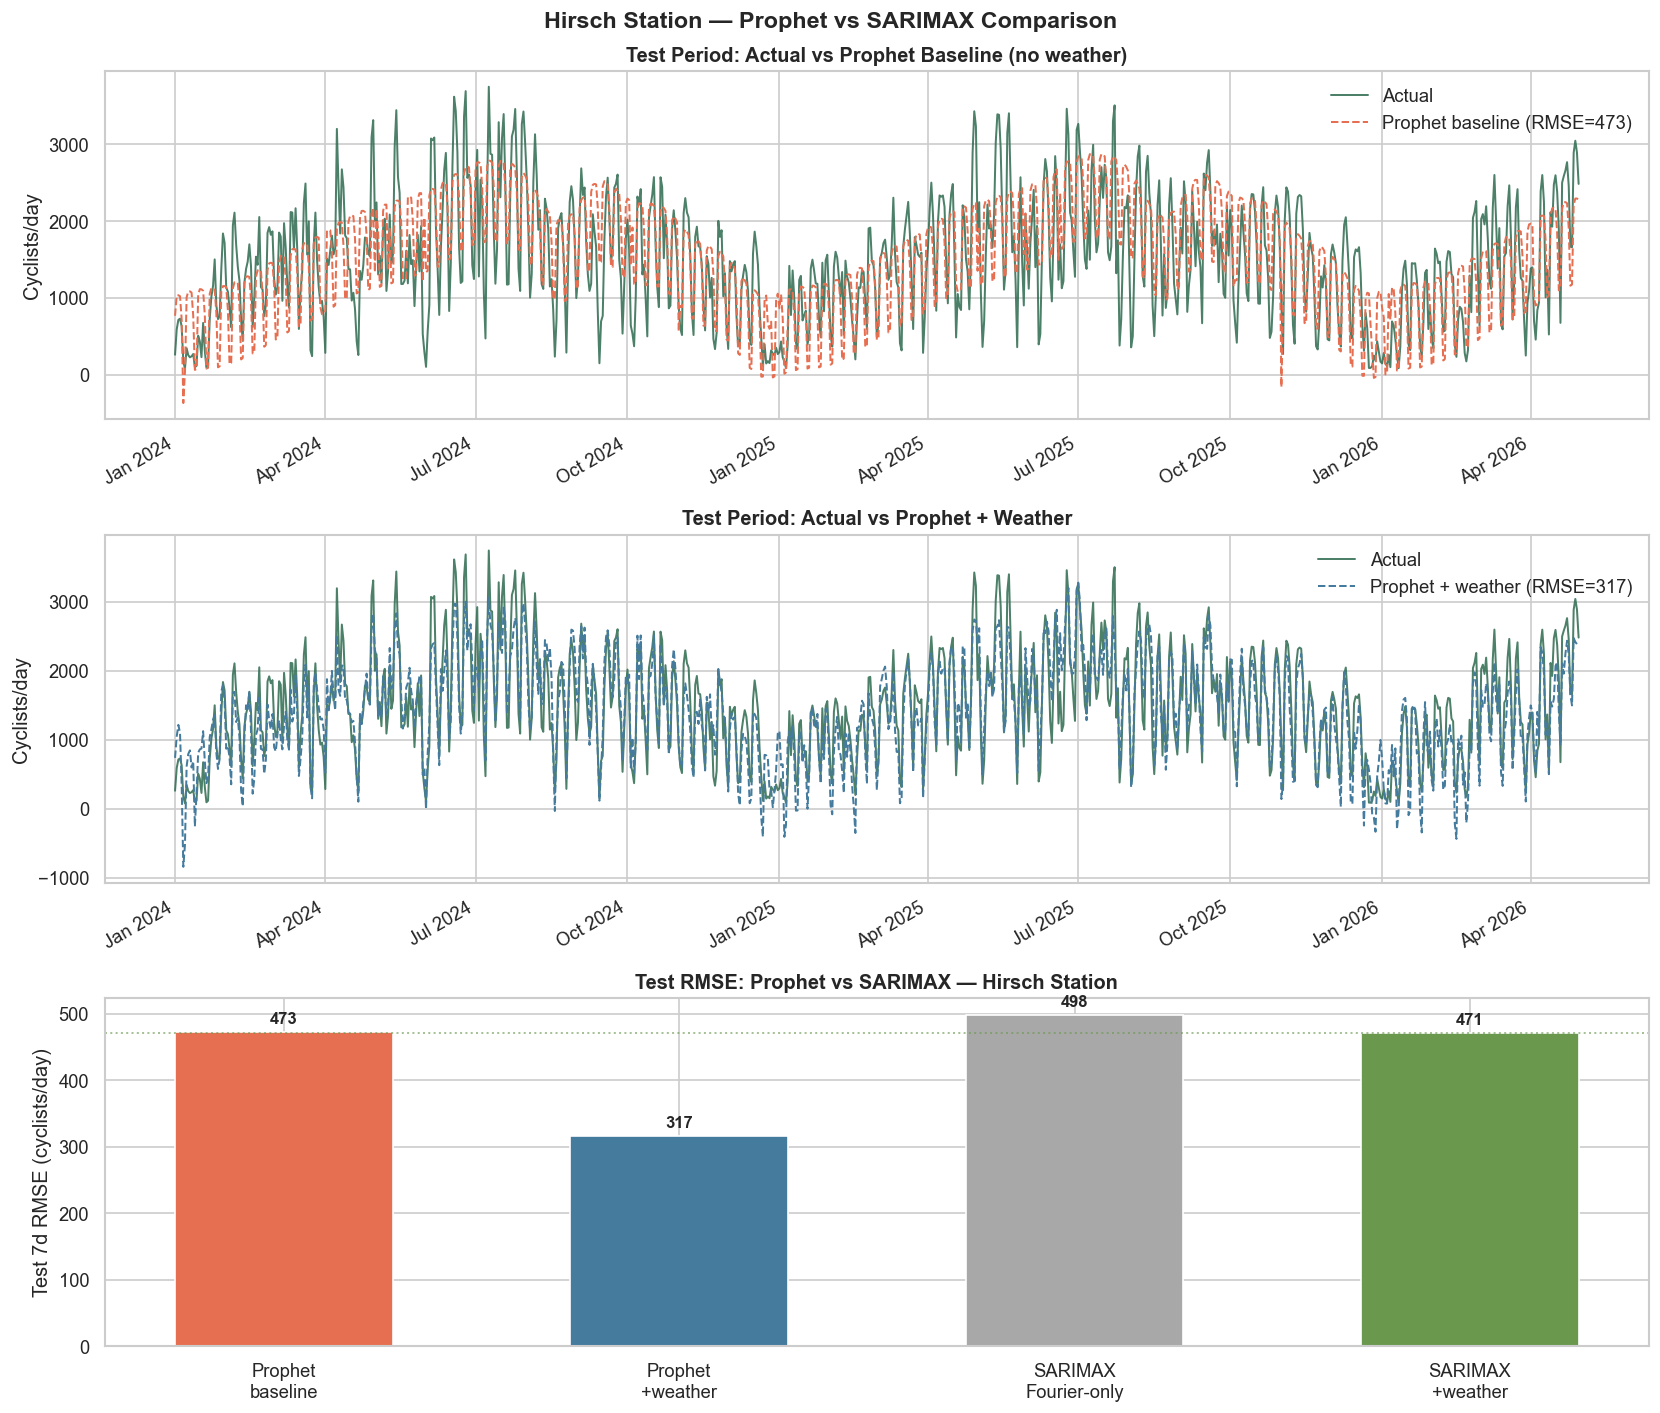

  saved → results/figures/nb08_fig_01_hirsch_prophet_predictions.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

test_dates = test_df['ds'].values
test_actual = test_df['y'].values

# Panel 1: Baseline Prophet on test
ax = axes[0]
ax.plot(test_dates, test_actual, color='#2d6a4f', lw=1.2, label='Actual', alpha=0.85)
ax.plot(test_dates, base_test_preds, color='#e76f51', lw=1.2, ls='--',
        label=f'Prophet baseline (RMSE={base_test_rmse:.0f})')
ax.set_title('Test Period: Actual vs Prophet Baseline (no weather)')
ax.set_ylabel('Cyclists/day')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 2: Prophet + weather on test
ax = axes[1]
ax.plot(test_dates, test_actual, color='#2d6a4f', lw=1.2, label='Actual', alpha=0.85)
ax.plot(test_dates, wx_test_preds, color='#457b9d', lw=1.2, ls='--',
        label=f'Prophet + weather (RMSE={wx_test_rmse:.0f})')
ax.set_title('Test Period: Actual vs Prophet + Weather')
ax.set_ylabel('Cyclists/day')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 3: RMSE bar comparison
ax = axes[2]
labels = ['Prophet\nbaseline', 'Prophet\n+weather', 'SARIMAX\nFourier-only', 'SARIMAX\n+weather']
rmse_vals = [base_test_rmse, wx_test_rmse, SARIMAX_FOURIER_RMSE, SARIMAX_FULL_RMSE]
colors = ['#e76f51', '#457b9d', '#a8a8a8', '#6a994e']
bars = ax.bar(labels, rmse_vals, color=colors, width=0.55, edgecolor='white')
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Test 7d RMSE (cyclists/day)')
ax.set_title('Test RMSE: Prophet vs SARIMAX — Hirsch Station')
ax.axhline(SARIMAX_FULL_RMSE, color='#6a994e', ls=':', lw=1.2, alpha=0.6)

fig.suptitle('Hirsch Station — Prophet vs SARIMAX Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('fig_01_hirsch_prophet_predictions')

### Seasonality Mode Detail

Quick check: how much does additive vs multiplicative matter for Prophet on this dataset?

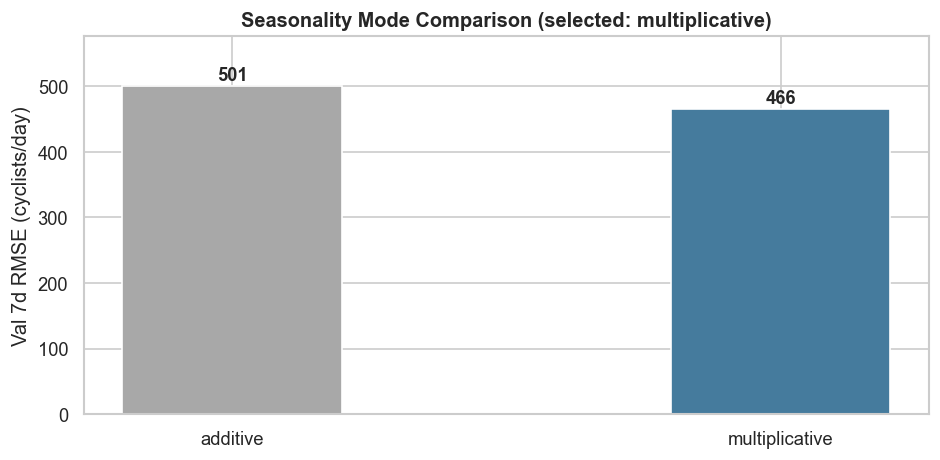

  saved → results/figures/nb08_fig_02_seasonality_mode_comparison.png
Additive vs multiplicative RMSE difference: 35.5 cyclists/day


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
modes = list(mode_results.keys())
rmses = [mode_results[m]['Val 7d RMSE'] for m in modes]
colors = ['#457b9d' if m == best_mode else '#a8a8a8' for m in modes]
bars = ax.bar(modes, rmses, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Val 7d RMSE (cyclists/day)')
ax.set_title(f'Seasonality Mode Comparison (selected: {best_mode})')
ax.set_ylim(0, max(rmses) * 1.15)
plt.tight_layout()
savefig('fig_02_seasonality_mode_comparison')
print(f'Additive vs multiplicative RMSE difference: {abs(rmses[0]-rmses[1]):.1f} cyclists/day')

## Part 7 — Artefact Export and Summary

In [9]:
perf_df.to_csv(TABLES / 'hirsch_prophet_performance.csv', index=False)
print('Saved: hirsch_prophet_performance.csv')

print('\n' + '='*60)
print('HIRSCH PROPHET RESULTS SUMMARY')
print('='*60)
print(f'Seasonality mode selected : {best_mode}')
print(f'\nProphet baseline          : Test RMSE = {base_test_rmse:.1f}, MAE = {base_test_mae:.1f}')
print(f'Prophet + weather         : Test RMSE = {wx_test_rmse:.1f}, MAE = {wx_test_mae:.1f}')
print(f'Weather gain (Prophet)    : {weather_gain_pct}% RMSE reduction')
print()
print(f'SARIMAX Fourier-only      : Test RMSE = {SARIMAX_FOURIER_RMSE}, MAE = {SARIMAX_FOURIER_MAE}')
print(f'SARIMAX Full model        : Test RMSE = {SARIMAX_FULL_RMSE}, MAE = {SARIMAX_FULL_MAE}')
print()
gap = wx_test_rmse - SARIMAX_FULL_RMSE
print(f'Prophet+weather vs SARIMAX+weather: {gap:+.1f} RMSE ({gap/SARIMAX_FULL_RMSE*100:+.1f}%)')
verdict = 'within ±5%' if abs(gap/SARIMAX_FULL_RMSE*100) <= 5 else 'outside ±5%'
print(f'Verdict: {verdict}')
print()
print(f'Figures saved: nb08_fig_01_hirsch_prophet_predictions, nb08_fig_02_seasonality_mode_comparison')

Saved: hirsch_prophet_performance.csv

HIRSCH PROPHET RESULTS SUMMARY
Seasonality mode selected : multiplicative

Prophet baseline          : Test RMSE = 472.8, MAE = 400.7
Prophet + weather         : Test RMSE = 316.5, MAE = 269.6
Weather gain (Prophet)    : 33.1% RMSE reduction

SARIMAX Fourier-only      : Test RMSE = 497.8, MAE = 420.8
SARIMAX Full model        : Test RMSE = 471.0, MAE = 403.3

Prophet+weather vs SARIMAX+weather: -154.5 RMSE (-32.8%)
Verdict: outside ±5%

Figures saved: nb08_fig_01_hirsch_prophet_predictions, nb08_fig_02_seasonality_mode_comparison
